In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F   # stateless functions (relu, softmax, etc.); preferred over
                                  # nn.ReLU() inside forward() since no learnable params are needed
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Automatically use GPU if available — training is significantly faster on CUDA.
# Falls back to CPU silently so the notebook runs anywhere without code changes.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [2]:
# ToTensor()  : converts PIL image with pixel range [0, 255] → float tensor [0.0, 1.0]
# Normalize() : applies (pixel - mean) / std per channel.
#               With mean=0.5, std=0.5 this maps [0, 1] → [-1, 1].
#               Zero-centred inputs help gradients flow more evenly during backprop.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# FashionMNIST: 70,000 grayscale 28×28 images across 10 clothing categories.
# train=True  → 60,000 labelled training samples
# train=False → 10,000 test samples (labels exist but we treat them as held-out)
train_full = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform
)

# Split training data 80/20 into train and validation sets.
# manual_seed(42) ensures the same images always go to the same split across runs,
# making metrics reproducible and results directly comparable.
train_size = int(0.8 * len(train_full))
val_size   = len(train_full) - train_size
train_dataset, val_dataset = random_split(
    train_full, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"Train: {train_size} | Validation: {val_size} | Test: {len(test_dataset)}")

# BATCH_SIZE=64: a common default that balances two trade-offs:
#   too small → noisy gradient estimates, very slow training
#   too large → smoother but less regularising gradients, higher memory use
BATCH_SIZE = 64

# shuffle=True on train_loader: randomises sample order each epoch so the model
# can't exploit any ordering pattern baked into the dataset.
# shuffle=False on val/test: order doesn't affect metrics and keeping it
# fixed makes debugging and reproducibility easier.
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 211kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.92MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 19.8MB/s]

Train: 48000 | Validation: 12000 | Test: 10000
Train batches: 750 | Val batches: 188


In [3]:
class FashionMNISTModel(nn.Module):
    """
    Custom two-branch fully-connected network.

    Architecture:
        Input (784)
              ↓
          hidden1  [784 → 16]
              ↓
      ┌───────────────────┐
      ↓                   ↓
    left1  [16 → 8]    right1  [16 → 12]
    left2  [8  → 8]    right2  [12 → 8]
    + residual skip
      ↓                   ↓
      └────── concat ──────┘  → [batch, 16]
                  ↓
          output_layer [16 → 10]

    The residual skip on the left branch helps gradients flow back through
    left2 without vanishing — a lightweight version of ResNet's core idea.
    """

    def __init__(self):
        # Must call super().__init__() to initialise nn.Module's internal
        # bookkeeping (parameter registration, hooks, etc.)
        super(FashionMNISTModel, self).__init__()

        # Shared stem: compresses 784 raw pixel values down to a 16-dim representation
        self.hidden1      = nn.Linear(784, 16)

        # Left branch — with residual skip connection
        self.left1        = nn.Linear(16, 8)
        self.left2        = nn.Linear(8, 8)    # in/out dims must match (both 8) for residual addition

        # Right branch — slightly wider path, no residual
        self.right1       = nn.Linear(16, 12)
        self.right2       = nn.Linear(12, 8)

        # Final classifier: 8 (left) + 8 (right) = 16 features → 10 class logits
        self.output_layer = nn.Linear(16, 10)

    def forward(self, x):
        # Images arrive shaped [batch, 1, 28, 28].
        # -1 tells PyTorch to infer the size automatically → [batch, 784]
        x          = x.view(x.size(0), -1)
        x          = F.relu(self.hidden1(x))

        # Left branch with residual:
        # Instead of learning the full mapping H(x), left2 only learns the
        # residual F(x) = H(x) - x, which is easier to optimise in practice.
        left       = F.relu(self.left1(x))
        left_input = left                        # snapshot before left2 transforms it
        left       = F.relu(self.left2(left))
        left       = left + left_input           # element-wise add; requires identical shapes [batch, 8]

        # Right branch — standard two-layer forward pass, no skip
        right      = F.relu(self.right1(x))
        right      = F.relu(self.right2(right))

        # Concatenate along feature dimension (dim=1), NOT the batch dimension (dim=0)
        combined   = torch.cat((left, right), dim=1)   # → [batch, 16]

        # Return raw logits — no softmax here.
        # CrossEntropyLoss applies log-softmax internally, so adding softmax here
        # would cause double-squashing and degrade performance.
        return self.output_layer(combined)


model = FashionMNISTModel().to(device)

# CrossEntropyLoss = LogSoftmax + NLLLoss fused into one numerically stable operation.
# It expects raw logits as input (not softmax probabilities).
criterion = nn.CrossEntropyLoss()

# Adam maintains a separate adaptive learning rate per parameter,
# which typically converges faster than vanilla SGD.
# lr=0.001 is Adam's well-tested default starting point.
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal trainable parameters: {total_params}")

FashionMNISTModel(
  (hidden1): Linear(in_features=784, out_features=16, bias=True)
  (left1): Linear(in_features=16, out_features=8, bias=True)
  (left2): Linear(in_features=8, out_features=8, bias=True)
  (right1): Linear(in_features=16, out_features=12, bias=True)
  (right2): Linear(in_features=12, out_features=8, bias=True)
  (output_layer): Linear(in_features=16, out_features=10, bias=True)
)

Total trainable parameters: 13246


In [4]:
EPOCHS = 20

# Initialise history lists before the loop.
# One value is appended per epoch; used later to plot training curves.
train_losses, val_losses         = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(EPOCHS):

    # ── Training phase ──────────────────────────────────────────────────────
    # model.train() tells layers like Dropout and BatchNorm to use their
    # training-time behaviour. This model doesn't have them, but calling
    # it is good practice so the code works correctly if they're added later.
    model.train()
    running_loss = 0.0
    correct = 0
    total   = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # PyTorch accumulates gradients across backward() calls by default.
        # We must zero them at the start of every batch, otherwise each step
        # would add gradients on top of the previous batch's gradients.
        optimizer.zero_grad()

        outputs = model(images)
        loss    = criterion(outputs, labels)

        loss.backward()   # compute dLoss/dParam for every parameter via backprop
        optimizer.step()  # apply the computed gradients to update all parameters

        # .item() extracts a plain Python float from the tensor.
        # Without it, loss retains a reference to the computation graph,
        # causing a memory leak that accumulates across epochs.
        running_loss += loss.item()

        # torch.max returns (values, indices) along a dimension.
        # We discard values (_) and use the index as the predicted class.
        _, predicted  = torch.max(outputs, 1)
        total        += labels.size(0)
        correct      += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)   # average loss per batch this epoch
    train_acc  = 100.0 * correct / total

    # ── Validation phase ────────────────────────────────────────────────────
    # model.eval() switches BatchNorm to use stored running statistics (not
    # batch statistics) and disables Dropout, giving deterministic outputs.
    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total   = 0

    # torch.no_grad() tells PyTorch not to build the computation graph.
    # Since we never call backward() here, skipping graph construction
    # saves memory and speeds up inference.
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)

            val_running_loss += loss.item()
            _, predicted  = torch.max(outputs, 1)
            val_total    += labels.size(0)
            val_correct  += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(val_loader)
    val_acc  = 100.0 * val_correct / val_total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch [{epoch+1:02d}/{EPOCHS}]  |  "
          f"Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.2f}%  |  "
          f"Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.2f}%")

Epoch [01/20]  |  Train Loss: 0.7127  Train Acc: 74.17%  |  Val Loss: 0.5242  Val Acc: 81.42%
Epoch [02/20]  |  Train Loss: 0.4696  Train Acc: 83.12%  |  Val Loss: 0.4542  Val Acc: 83.52%
Epoch [03/20]  |  Train Loss: 0.4299  Train Acc: 84.55%  |  Val Loss: 0.4372  Val Acc: 84.20%
Epoch [04/20]  |  Train Loss: 0.4068  Train Acc: 85.20%  |  Val Loss: 0.4089  Val Acc: 85.53%
Epoch [05/20]  |  Train Loss: 0.3922  Train Acc: 85.84%  |  Val Loss: 0.4160  Val Acc: 85.51%
Epoch [06/20]  |  Train Loss: 0.3785  Train Acc: 86.35%  |  Val Loss: 0.3965  Val Acc: 85.78%
Epoch [07/20]  |  Train Loss: 0.3688  Train Acc: 86.70%  |  Val Loss: 0.3945  Val Acc: 85.90%
Epoch [08/20]  |  Train Loss: 0.3596  Train Acc: 86.96%  |  Val Loss: 0.4101  Val Acc: 85.50%
Epoch [09/20]  |  Train Loss: 0.3538  Train Acc: 87.22%  |  Val Loss: 0.4059  Val Acc: 85.84%
Epoch [10/20]  |  Train Loss: 0.3461  Train Acc: 87.46%  |  Val Loss: 0.3918  Val Acc: 86.11%
Epoch [11/20]  |  Train Loss: 0.3409  Train Acc: 87.74%  |  

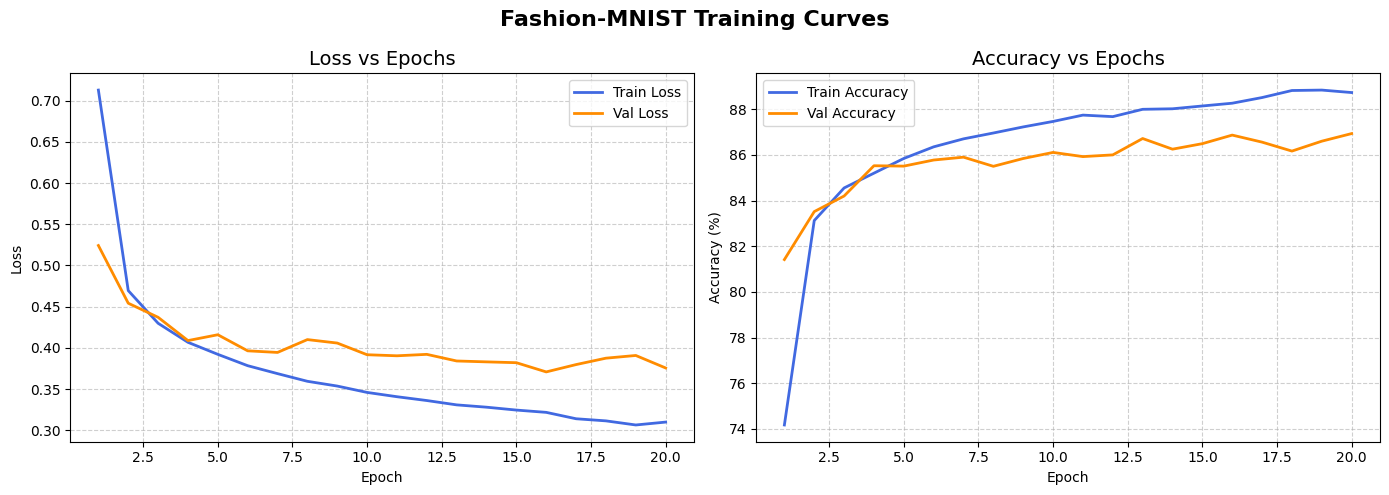

Plots saved as training_plots.png


In [5]:
# Safety check: if training was interrupted mid-run, the history lists will be
# shorter than EPOCHS. Plotting partial data would produce misleading x-axis
# alignment, so we fail loudly here rather than silently showing a wrong chart.
assert len(train_losses) == EPOCHS, f"Expected {EPOCHS} epochs, got {len(train_losses)}"

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, EPOCHS + 1)

axes[0].plot(epochs_range, train_losses, label='Train Loss', color='royalblue',  linewidth=2)
axes[0].plot(epochs_range, val_losses,   label='Val Loss',   color='darkorange', linewidth=2)
axes[0].set_title('Loss vs Epochs', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].plot(epochs_range, train_accuracies, label='Train Accuracy', color='royalblue',  linewidth=2)
axes[1].plot(epochs_range, val_accuracies,   label='Val Accuracy',   color='darkorange', linewidth=2)
axes[1].set_title('Accuracy vs Epochs', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.suptitle('Fashion-MNIST Training Curves', fontsize=16, fontweight='bold')
plt.tight_layout()
# bbox_inches='tight' expands the bounding box of the saved image to include
# the suptitle, which sits above the subplot area and would otherwise be clipped.
plt.savefig('training_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plots saved as training_plots.png")

In [6]:
# state_dict() returns an OrderedDict of all learnable tensors (weights & biases).
# It does NOT store the model architecture, so to reload these weights later
# you must first rebuild the model and then call load_state_dict():
#
#     model = FashionMNISTModel()
#     model.load_state_dict(torch.load('model_weights.pth'))
#     model.eval()
#
# Using torch.save (vs pickle) is the PyTorch standard — it handles tensor
# serialisation correctly across devices and versions.
torch.save(model.state_dict(), 'model_weights.pth')
print("Model weights saved as model_weights.pth")

Model weights saved as model_weights.pth


In [7]:
# Switch to eval mode and disable gradients for the same reasons as validation:
# deterministic outputs and no unnecessary computation graph overhead.
model.eval()
all_predictions = []

with torch.no_grad():
    for images, _ in test_loader:     # labels discarded; not needed for inference
        images  = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        # .cpu() moves the tensor back to CPU memory before .numpy().
        # numpy has no access to GPU memory, so this step is required
        # whenever the model is running on CUDA.
        all_predictions.extend(predicted.cpu().numpy())

submission_df = pd.DataFrame({
    'ImageId': range(1, len(all_predictions) + 1),
    'Label':   all_predictions
})

# index=False prevents pandas from writing its internal row numbers (0, 1, 2…)
# as a leading column in the CSV, which would break the expected submission format.
submission_df.to_csv('submission.csv', index=False)
print(f"submission.csv saved with {len(submission_df)} rows")
print(submission_df.head(10))

submission.csv saved with 10000 rows
   ImageId  Label
0        1      9
1        2      2
2        3      1
3        4      1
4        5      6
5        6      1
6        7      4
7        8      6
8        9      5
9       10      7


In [8]:
# files.download() triggers a browser download dialog for each file.
# Note: this only works inside a Google Colab runtime.
# If running locally, the files are already saved to disk — skip this cell.
from google.colab import files

files.download('model_weights.pth')
files.download('submission.csv')
files.download('training_plots.png')

print("All files downloaded — upload them to your GitHub repository.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All files downloaded — upload them to your GitHub repository.


In [9]:
print("\n" + "="*60)
print("SUBMISSION CHECKLIST")
print("="*60)
print(f"  [✓] Final notebook         — Spider_BaseTask_Final.ipynb")
print(f"  [✓] Saved model weights    — model_weights.pth")
print(f"  [✓] Test predictions       — submission.csv")
print(f"  [✓] Loss & accuracy plots  — training_plots.png (+ inline)")
print(f"\nFinal Validation Accuracy   : {val_accuracies[-1]:.2f}%")
print(f"Final Validation Loss       : {val_losses[-1]:.4f}")
print("="*60)


SUBMISSION CHECKLIST
  [✓] Final notebook         — Spider_BaseTask_Final.ipynb
  [✓] Saved model weights    — model_weights.pth
  [✓] Test predictions       — submission.csv
  [✓] Loss & accuracy plots  — training_plots.png (+ inline)

Final Validation Accuracy   : 86.93%
Final Validation Loss       : 0.3757
